# <span style="color:teal"> Lezione 4 </span>
## <span style="color:turquoise"> Esercizio 4.1 </span>
In questo esercizio abbiamo considerato un sistema tridimensionale composto da un gas rareffato di $N=108$ particelle a temperatura iniziale $T^*=1.9$ e densità $\rho^*=0.8$. Per queste condizioni di temperatura e densità, il gas si comporta come un gas ideale: le interazioni tra le particelle sono trascurabili rispetto all'energia cinetica media, e la distribuzione delle velocità è quindi ben descritta dalla distribuzione di Maxwell-Boltzmann. In unità ridotte di Lennard-Jones, è data da:
$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$

Per calcolare la distribuzione di Maxwell-Boltzmann delle velocità abbiamo costruito un istogramma da $30$ bin con range $[0, v_{max}]$, dove $v_{max}=3\sqrt{3T^*}$ è stata scelta come il triplo della velocità quadratica media $v_{rms}=\sqrt{3T^*}$, in modo tale da includere la quasi totalità della distribuzione che decade rapidamente per $v$>>$v_{rms}$.


Inoltre, abbiamo bisogno di normalizzare l'istogramma ottenuto dalla simulazione, dato che deve approssimare una distribuzione di probabilità.     
Aprrossimando si ha: $\int^{v_{max}}_0 \mathcal{N}p(v)dv =1 \longrightarrow \sum _{i=1}^{30}\mathcal{N}p(v)\Delta v =1$; dove 30 è il numero di bin, $\Delta v$ la larghezza (costante) dei bin e $p(v)$ è la distribuzione di probabilità che all'interno della sommatoria prende il significato di numero di conteggi per bin.  
Dunque, poichè il numero di particelle è fissato, otteniamo la costante di normalizzazione $\mathcal{N}= \frac{1}{N \cdot \Delta v}$.

La distribuzione teorica e i dati ottenuti dalla nostra simulazione vengono graficati assieme per verificarne l'accordo:   
- Rappresentiamo i nostri dati con dei punti che hanno come coordinata sulle ascisse la velocità al centro del bin di appartenenza.   
- Costruiamo la distribuzione di Maxwell-Boltzmann teorica utilizzando la temperatura media finale ottenuta dalla simulazione. 

In [1]:
# stampa temperatura media finale
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats

N=30

vel = np.arange(N)
pofv_prog = np.zeros(N)
err_prog = np.zeros(N)

dati=np.loadtxt("Esercizio4.1/OUTPUT/pofv.dat")
vel=dati[:,0]
pofv_prog=dati[:,2]
err_prog=dati[:,3]

#prendo dal file temperatura.dat l'ultima temperatura media progressiva
with open("Esercizio4.1/OUTPUT/temperature.dat") as f:
    last_line = f.readlines()[-1]
T = float(last_line.split()[2])
print("temperatura media finale = ", T)

temperatura media finale =  1.40937


Per verificare di aver fatto una normalizzazione corretta calcoliamo l'area sotto i nostri dati simulati e ci aspettiamo di ottenere circa 1.

In [2]:
# stampa valore area
integrale = np.trapezoid(pofv_prog, vel)
print("valore area sotto la curva =", integrale)

valore area sotto la curva = 0.9990834881011524


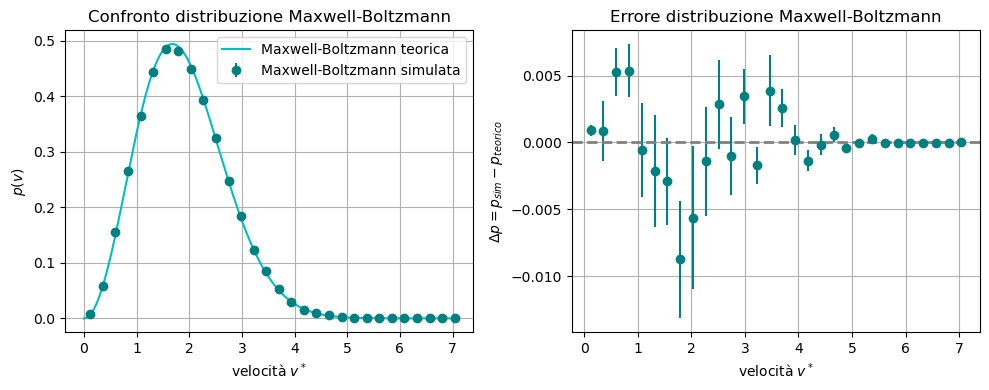

In [3]:
#plot maxwell-boltzmann e residui
def maxwell_boltzmann(v, m, kB, T):
    factor = 4 * np.pi * (m / (2 * np.pi * kB * T)) ** (3/2)
    return factor * v**2 * np.exp(-m * v**2 / (2 * kB * T))

v_theory = np.linspace(0, max(vel), 500)
P_MB = maxwell_boltzmann(v_theory, 1, 1, T)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.errorbar(vel,pofv_prog,yerr=err_prog, fmt='o', color='teal', ecolor='teal', label="Maxwell-Boltzmann simulata")
ax1.plot(v_theory, P_MB, label="Maxwell-Boltzmann teorica", color="c")
ax1.grid(True)
ax1.set_xlabel('velocità $v^*$')
ax1.set_ylabel("$p(v)$")
ax1.set_title("Confronto distribuzione Maxwell-Boltzmann")
ax1.legend()


v_theory = vel
P_MB = maxwell_boltzmann(v_theory, 1, 1, T)


ax2.errorbar(v_theory, (pofv_prog-P_MB), yerr=err_prog, fmt='o', color='teal', ecolor="teal")
ax2.axhline(y=0, color='grey', linestyle='--', linewidth=2)
ax2.grid(True)
ax2.set_xlabel('velocità $v^*$')
ax2.set_ylabel("$\Delta p = p_{sim}-p_{teorico}$")
ax2.set_title("Errore distribuzione Maxwell-Boltzmann")

plt.tight_layout()
plt.show()

Il primo grafico mostra il confronto tra la distribuzione di Maxwell-Boltzmann simulata e quella teorica, mentre il secondo rappresenta la differenza tra i dati simulati e quelli attesi con il loro errore. Si può concludere che i dati simulati sono in ottimo accordo con la previsione analitica su tutto il range di velocità considerato: la maggior parte rientra entro 1$\sigma$ dalla curva teorica e la restante entro 2-3$\sigma$.

## <span style="color:turquoise"> Esercizio 4.2 </span>

In questo esercizio abbiamo considerato un gas di Argon ($\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) con densità $\rho^*=0.05$, a temperatura iniziale $T^*=2.0$ e troncando il potenziale di Lennard-Jones a $r_c=5.0$.

Siamo partiti da una configurazione a bassissima entropia:
- gli atomi sono disposti in un reticolo fcc che occupa metà dello spazio disponibile
- la distribuzione di velocità iniziale è $p_\delta(v^*,T^*) = \delta\left( v^* - v_{T^*}\right)$, ovvero ogni atomo ha una velocità $v=\pm v_{T^*}$ per una delle sue componenti scelta in modo casuale. Abbiamo usato $v_{T^*}=\sqrt{3T^*}$, cioè la velocità quadratica media.

Il nostro obiettivo è mostrare che, col passare del tempo, la distribuzione delle velocità va sempre di più ad approssimare la distribuzione di Maxwell-Boltzmann; per la simualazione vengono usati $250$ blocchi, ognuno composto da $200$ step, e decidiamo di graficare solamente dopo i blocchi 2, 25, 100 e 250.  
Anche in questo caso, per costruire la distribuzione di Maxwell-Boltzmann teorica utilizziamo la temperatura media finale ottenuta dalla simulazione per il blocco considerato.

In [4]:
# temperatura finali
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats

N = 30  # numero di punti (righe) da leggere per ogni blocco

# blocchi di simulazione da analizzare (gli altri vengono ignorati)
blocchi = [2, 25, 100, 250]

# dizionario annidato: per ogni blocco, liste di velocità, probabilità ed errori
data = {b: {"v": [], "pofv": [], "err": []} for b in blocchi}

current_block = None   # blocco attuale letto dal file
capture = False        # True solo se il blocco corrente è tra quelli di interesse
rows_left = 0          # righe rimanenti da leggere nel blocco corrente

with open("Esercizio4.2/OUTPUT/pofv.dat", "r") as f:
    for line in f:
        line = line.strip()

        # riconoscimento intestazione blocco (es. "BLOCCO 25")
        if line.startswith("BLOCCO"):
            parts = line.split()
            current_block = int(parts[1])                    # numero del blocco
            capture = current_block in blocchi               # attiva lettura solo se blocco di interesse
            rows_left = N if capture else 0                  # imposta quante righe leggere
            continue

        # lettura dei dati del blocco, fino a N righe
        if capture and rows_left > 0:
            parts = line.split()

            if len(parts) == 4:                              # riga valida: deve avere esattamente 4 colonne
                v    = float(parts[0])                       # velocità
                pofv = float(parts[2])                       # P(v): probabilità della velocità v
                err  = float(parts[3])                       # errore statistico su P(v)
                # parts[1] non viene letta (colonna ignorata)

                data[current_block]["v"].append(v)
                data[current_block]["pofv"].append(pofv)
                data[current_block]["err"].append(err)

                rows_left -= 1                               # decrementa il contatore di righe rimaste

# dizionario blocco -> temperatura media cumulativa
temperature = {}

with open("Esercizio4.2/OUTPUT/temperature.dat", "r") as f:
    for line in f:
        line = line.strip()

        # salta righe vuote, commenti e intestazioni
        if not line or line.startswith("#") or "BLOCK" in line:
            continue

        parts = line.split()
        b = int(parts[0])      # numero del blocco
        t = float(parts[2])    # temperatura media progressiva (terza colonna)

        # salva solo i blocchi di interesse; se il blocco appare più volte
        # viene tenuto l'ultimo valore (media progressiva finale)
        if b in blocchi:
            temperature[b] = t

# stampa la temperatura media finale per ogni blocco di interesse
for b in blocchi:
    print("dopo il blocco", b, "la temperatura media è", temperature.get(b))

dopo il blocco 2 la temperatura media è 2.03768
dopo il blocco 25 la temperatura media è 1.50654
dopo il blocco 100 la temperatura media è 1.37493
dopo il blocco 250 la temperatura media è 1.34626


Poiché la simulazione restituisce i dati in unità di Lennard-Jones, per rappresentare i risultati per l'Argon in unità SI è necessario convertire le velocità tramite la relazione: 
$$v=\sqrt{\frac{\epsilon}{m}} v^*$$
dove $v^*$ è la velocità in unità ridotte e $\sqrt{\epsilon/m}$ è la velocità caratteristica del sistema. 


Quindi moltiplichiamo i valori sull'asse delle velocità per questo fattore, mentre dividiamo i valori della distribuzione $p(v)$ per lo stesso, in modo da preservare la normalizzazione dell'istogramma.

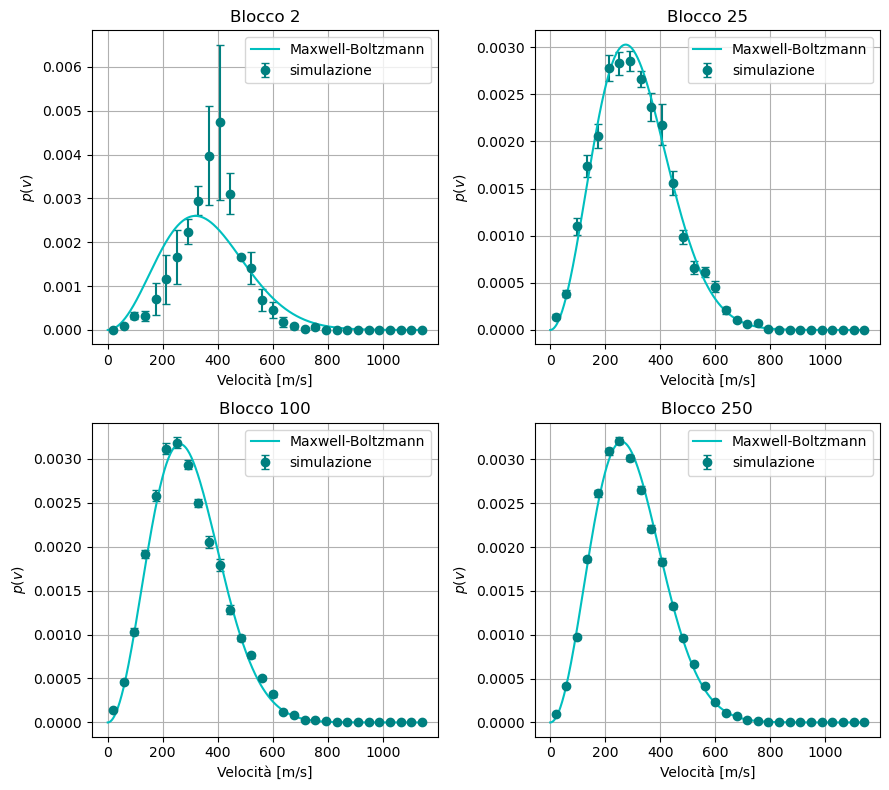

In [5]:
# grafici convergenza

# costanti fisiche
kB = 1.38065e-23           # J/K — costante di Boltzmann
m = 39.948 * 1.66054e-27   # kg — massa dell'Argon
sigma = 0.34e-9             # m — parametro LJ 
eps_over_kB = 120.0         # K — profondità del pozzo LJ in unità di temperatura
eps = kB * eps_over_kB      # J — energia caratteristica LJ

v_unit = np.sqrt(eps / m)   # m/s — unità di velocità ridotta della simulazione

# griglia 2x2 di subplot, uno per ogni blocco
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
axes = axes.flatten()  # appiattisce la matrice 2x2 in un array 1D per iterare facilmente

for i, block in enumerate(sorted(blocchi)):  # itera sui blocchi in ordine crescente

    # riconversione dalle unità ridotte a unità fisiche SI
    v    = np.array(data[block]["v"])    * v_unit   
    pofv = np.array(data[block]["pofv"]) / v_unit   
    err  = np.array(data[block]["err"])  / v_unit   

    # punti simulazione con barre di errore
    axes[i].errorbar(v, pofv, yerr=err,
                     fmt='o', capsize=3,
                     color='teal', ecolor='teal',
                     label='simulazione')

    # converte temperatura del blocco a Kelvin
    T = temperature[block]          
    T_fisico = T * eps_over_kB 

    # curva teorica di Maxwell-Boltzmann
    v_theory = np.linspace(0, np.max(v), 500)            # asse velocità per la curva teorica
    P_MB = maxwell_boltzmann(v_theory, m, kB, T_fisico)  # distribuzione MB analitica
    axes[i].plot(v_theory, P_MB, label="Maxwell-Boltzmann", color="c")
    axes[i].set_title(f"Blocco {block}")
    axes[i].set_xlabel("Velocità [m/s]")
    axes[i].set_ylabel("$p(v)$")
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

I quattro grafici mostrano l'evoluzione della distribuzione delle velocità $p(v)$ a blocchi temporali crescenti (2, 25, 100, 250), confrontata con la distribuzione teorica di Maxwell-Boltzmann. Ai blocchi iniziali il sistema è ancora lontano dall'equilibrio: la distribuzione simulata presenta una forma irregolare e barre d'errore elevate. All'aumentare del blocco, la curva simulata converge progressivamente verso la Maxwell-Boltzmann, con errori sempre più piccoli e un accordo via via migliore.

## <span style="color:turquoise"> Esercizio 4.3 </span>
Anche in questo esercizio abbiamo considerato un gas di Argon ($\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) con densità $\rho^*=0.05$, a temperatura iniziale $T^*=2.0$ e troncando il potenziale di Lennard-Jones a $r_c=5.0$.

È stato chiesto di partire dalla configurazione finale dell'esercizio precedente e di invertire la direzione dello scorrere del tempo, osservando il comportamento dell'energia potenziale $U/N$ e della temperatura $T$ in funzione del tempo $t$ per una configurazione breve da $5 \cdot 10^3$ step e una lunga da $5 \cdot 10^4$ step. 

Per implementare il time reversal è stato aggiunto il flag booleano `_time_reverse` nella classe System, il cui valore viene letto dal file di input e determina se la simulazione deve essere eseguita con inversione temporale: se è true, dopo l'inizializzazione delle velocità viene chiamata la funzione `reverse_velocities()`, che ne inverte il segno e scambia la posizione precedente $x_{old}$ e quella successiva $x_{new}$, cosicché il Verlet integra automaticamente nella direzione temporale opposta; invece se è false, la simulazione procede normalmente in avanti.

Poiché la simulazione restituisce i dati in unità di Lennard-Jones, per rappresentare i risultati per l'Argon in unità SI è necessario convertire le grandezze fisiche analizzate tramite le seguenti relazioni, dove con $^*$ sono indicate le grandezze in unità LJ: 
$$U/N= \epsilon\cdot (U/N)^* \qquad \qquad  T= \frac{\epsilon}{k_B}\cdot  T^* \qquad \qquad  t=\sigma \sqrt{\frac{m}{\epsilon}} \cdot t^* $$

Si è scelto di rappresentare sia i valori istantanei sia i valori medi dell'energia potenziale $U/N$ e della temperatura $T$. Per i valori istantanei, la simulazione con time reversal è stata riportata con l'asse temporale invertito, così da riuscire a verificare se la traiettoria si sovrappone con quella forward, ovvero se il sistema ritorna effettivamente alla configurazione iniziale. Invece, per i valori medi, entrambe le simulazioni sono state riportate con il tempo forward, in modo da confrontare la convergenza allo stesso valore di equilibrio.

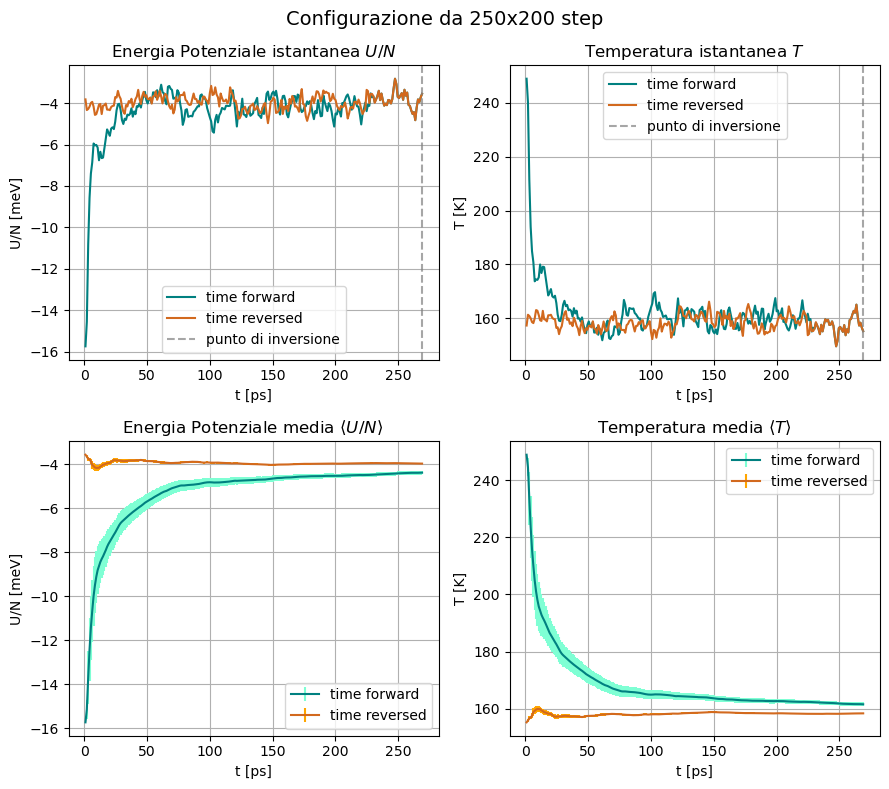

In [8]:
# grafici 250x200
import numpy as np
import matplotlib.pyplot as plt


t_unit=sigma * np.sqrt(m / eps)
ps=1e-12
eV=1.60218e-19
meV=eV/1000

M = 250
DELTA = 0.002
t_block = M * DELTA * t_unit / ps

# TIME FORWARD
dati = np.loadtxt("Esercizio4.3/OUTPUT/potential_energy_for250.dat")
en_pot_forward   = dati[:, 1]* eps / meV
en_pot_ave_forward   = dati[:, 2]* eps / meV
err_pot_forward  = dati[:, 3]* eps / meV

dati_temp = np.loadtxt("Esercizio4.3/OUTPUT/temperature_for250.dat")
temp_forward     = dati_temp[:, 1]* eps_over_kB
temp_ave_forward     = dati_temp[:, 2]* eps_over_kB 
err_temp_forward = dati_temp[:, 3]* eps_over_kB 

time_forward = dati[:, 0] * t_block  
t_end = time_forward[-1]             

# TIME REVERSED
dati2 = np.loadtxt("Esercizio4.3/OUTPUT/potential_energy_rev250.dat")
en_pot_rev   = dati2[:, 1]* eps / meV
en_pot_ave_rev   = dati2[:, 2]* eps / meV
err_pot_rev  = dati2[:, 3]* eps / meV

dati_temp2 = np.loadtxt("Esercizio4.3/OUTPUT/temperature_rev250.dat")
temp_rev     = dati_temp2[:, 1]* eps_over_kB
temp_ave_rev     = dati_temp2[:, 2]* eps_over_kB 
err_temp_rev = dati_temp2[:, 3]* eps_over_kB 

# Inversione asse temporale del time reversal:
# il file rev contiene i blocchi numerati 1, 2, ..., M come se il tempo scorresse in avanti
# bisogna rispecchiare l'asse temporale attorno al punto di inversione t_end
time_reversed = t_end + t_block - dati2[:, 0] * t_block

# Dopo la riflessione l'array è in ordine decrescente -> viene riordinato in ordine crescente
idx = np.argsort(time_reversed)
time_reversed = time_reversed[idx]
en_pot_rev    = en_pot_rev[idx]
temp_rev      = temp_rev[idx]

# --- PLOT ---
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(9, 8))
fig.suptitle('Configurazione da 250x200 step', fontsize=14)

ax1.plot(time_forward,  en_pot_forward, color='teal', label="time forward")
ax1.plot(time_reversed, en_pot_rev, color='chocolate',     label="time reversed")
ax1.axvline(x=t_end, color='gray', linestyle='--', alpha=0.7, label="punto di inversione")
ax1.grid(True)
ax1.set_xlabel('t [ps]')
ax1.set_ylabel('U/N [meV]')
ax1.set_title('Energia Potenziale istantanea $U/N$')
ax1.legend()

ax2.plot(time_forward,  temp_forward,color='teal', label="time forward")
ax2.plot(time_reversed, temp_rev, color='chocolate',     label="time reversed")
ax2.axvline(x=t_end, color='gray', linestyle='--', alpha=0.7, label="punto di inversione")
ax2.grid(True)
ax2.set_xlabel('t [ps]')
ax2.set_ylabel('T [K]')
ax2.set_title('Temperatura istantanea $T$')
ax2.legend()

ax3.errorbar(time_forward,  en_pot_ave_forward, yerr=err_pot_forward, color='teal',   ecolor='aquamarine', label="time forward")
ax3.errorbar(time_forward, en_pot_ave_rev,     yerr=err_pot_rev, color='chocolate', ecolor='orange',     label="time reversed")
ax3.grid(True)
ax3.set_xlabel('t [ps]')
ax3.set_ylabel('U/N [meV]')
ax3.set_title(fr'Energia Potenziale media $\langle U/N \rangle $ ')
ax3.legend()

ax4.errorbar(time_forward,  temp_ave_forward, yerr=err_temp_forward, color='teal',   ecolor='aquamarine', label="time forward")
ax4.errorbar(time_forward, temp_ave_rev,     yerr=err_temp_rev, color='chocolate', ecolor='orange',     label="time reversed")
ax4.grid(True)
ax4.set_xlabel('t [ps]')
ax4.set_ylabel('T [K]')
ax4.set_title(fr'Temperatura media $\langle T \rangle$')
ax4.legend()

plt.tight_layout()
plt.show()

Per quanto rigurda la simulazione lunga, si può osservare che l'energia potenziale e la temperatura istantanee time reversed sono sovrapponibili a quelle forward solo per i primi $\sim 50$ ps (corrispondenti a $\sim 10^4$ step). In questo intervallo gli errore numerici accumulati dal Verlet sono ancora sufficientemente piccoli da preservare la reversibilità della traiettoria; superata questa soglia, gli errori si amplificano notevolmente e le grandezze time reversed iniziano a oscillare attorno al valor medio di equilibrio, evidenziando l'impossibilità fisica che il sistema ritorni spontaneamente a una configurazione a entropia minore. 

Anche le grandezze medie non convergono allo stesso valore, poiché il Verlet, nel time reversal, non riesce più a ricostruire fedelmente la configurazione forward dopo un numero sufficientemente elevato di passi.

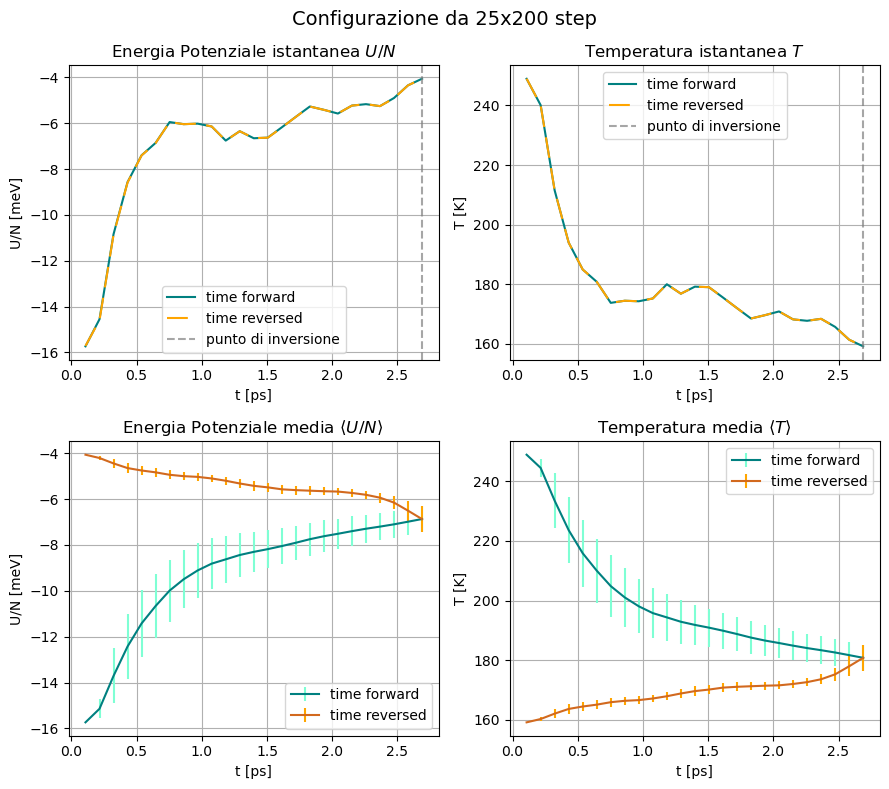

In [7]:
#grafici 25x200
import numpy as np
import matplotlib.pyplot as plt

M = 25
DELTA = 0.002
t_block = M * DELTA * t_unit / ps
# TIME FORWARD
dati = np.loadtxt("Esercizio4.3/OUTPUT/potential_energy_for25.dat")
en_pot_forward   = dati[:, 1] * eps / meV
en_pot_ave_forward   = dati[:, 2] * eps / meV
err_pot_forward  = dati[:, 3] * eps / meV

dati_temp = np.loadtxt("Esercizio4.3/OUTPUT/temperature_for25.dat")
temp_forward     = dati_temp[:, 1] * eps_over_kB
temp_ave_forward     = dati_temp[:, 2] * eps_over_kB 
err_temp_forward = dati_temp[:, 3] * eps_over_kB 

time_forward = dati[:, 0] * t_block  
t_end = time_forward[-1]             

# TIME REVERSED
dati2 = np.loadtxt("Esercizio4.3/OUTPUT/potential_energy_rev25.dat")
en_pot_rev   = dati2[:, 1] * eps / meV
en_pot_ave_rev   = dati2[:, 2] * eps / meV
err_pot_rev  = dati2[:, 3] * eps / meV

dati_temp2 = np.loadtxt("Esercizio4.3/OUTPUT/temperature_rev25.dat")
temp_rev     = dati_temp2[:, 1] * eps_over_kB
temp_ave_rev     = dati_temp2[:, 2] * eps_over_kB
err_temp_rev = dati_temp2[:, 3] * eps_over_kB 

# Inverto asse temporale del time reversed
time_reversed = t_end + t_block - dati2[:, 0] * t_block
idx = np.argsort(time_reversed)
time_reversed = time_reversed[idx]
en_pot_rev    = en_pot_rev[idx]
temp_rev      = temp_rev[idx]

# --- PLOT ---
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(9, 8))
fig.suptitle('Configurazione da 25x200 step', fontsize=14)

ax1.plot(time_forward,  en_pot_forward, color='teal', label="time forward")
ax1.plot(time_reversed, en_pot_rev, color='orange', ls='--',  dashes=(10, 5),    label="time reversed")
ax1.axvline(x=t_end, color='gray', linestyle='--', alpha=0.7, label="punto di inversione")
ax1.grid(True)
ax1.set_xlabel('t [ps]')
ax1.set_ylabel('U/N [meV]')
ax1.set_title('Energia Potenziale istantanea $U/N$')
ax1.legend()

ax2.plot(time_forward,  temp_forward,color='teal', label="time forward")
ax2.plot(time_reversed, temp_rev, color='orange', ls='--',  dashes=(10, 5),    label="time reversed")
ax2.axvline(x=t_end, color='gray', linestyle='--', alpha=0.7, label="punto di inversione")
ax2.grid(True)
ax2.set_xlabel('t [ps]')
ax2.set_ylabel('T [K]')
ax2.set_title('Temperatura istantanea $T$')
ax2.legend()

ax3.errorbar(time_forward,  en_pot_ave_forward, yerr=err_pot_forward, color='teal',   ecolor='aquamarine', label="time forward")
ax3.errorbar(time_forward, en_pot_ave_rev,     yerr=err_pot_rev, color='chocolate', ecolor='orange',     label="time reversed")
ax3.grid(True)
ax3.set_xlabel('t [ps]')
ax3.set_ylabel('U/N [meV]')
ax3.set_title(fr'Energia Potenziale media $\langle U/N \rangle $ ')
ax3.legend()

ax4.errorbar(time_forward,  temp_ave_forward, yerr=err_temp_forward, color='teal',   ecolor='aquamarine', label="time forward")
ax4.errorbar(time_forward, temp_ave_rev, yerr=err_temp_rev, color='chocolate', ecolor='orange',     label="time reversed")
ax4.grid(True)
ax4.set_xlabel('t [ps]')
ax4.set_ylabel('T [K]')
ax4.set_title(fr'Temperatura media $\langle T \rangle $ ')
ax4.legend()

plt.tight_layout()
plt.show()

Per quanto riguarda la simulazione breve, si può osservare che l'energia potenziale e la temperatura istantanee time reversed sono esattamente sovrapponibili a quelle forward per tutta la traiettoria; infatti, essendo il numero di passi inferiore alla soglia critica $\sim 10^4$ osservata in precedenza, gli errori numerici del Verlet non hanno avuto tempo di amplificarsi significativamente e il sistema time reversed riesce ancora a ripercorrere fedelmente la traiettoria originale, evidenziando la reversibilità delle equazioni del moto. 

Anche le grandezze medie, come atteso, convergono allo stesso valore nel punto di inversione, confermando la coerenza della traiettoria percorsa nei due sensi temporali.